<a href="https://colab.research.google.com/github/emilchafigoulline/Data-Science/blob/main/Unit6/Unit6ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 6 Exercises: Is my model good?

#### Over and Under fitting, Model Visualization, and Model/Variable Selection Concepts

These exercises are meant to get you to think about the model and variable selection process, and consider how we determine if a model is "good".

**Task1**:

Does elpd_loo mean anything if we only have one model?

No, elpd_loo is only useful in context with two models, with the one having a more positive elpd_loo value being generally more accurate in the case of models where points don't hold too much leverage.

**Task2**:

Describe overfitting, in the context of this course

Overfitting is when we overfit the model to the points we are provided, leading to an inability of the model to adapt to new points added. Our predictions don't adjust to new data.

**Task3**:

How do we mitigate overfitting?

We mitigate overfitting by using priors. This is because we don't want to fit the curve only to the data we have, but also to model some of the variation we would expect within the real world. This makes our model more adaptable.

**Task4**:

How do we mitigate underfitting?

To mitigate underfitting, we can make the model more accurate to our data, either by improving our priors to make them more definitive, or by collecting more data in order to improve the confidence of the model.

**Task5**:

Why would we want more than one predictor in a model?

When we are creating a model, we are trying to model as closely to reality as possible. As such, it is absurd to try and predict reality with only one variable when we are certain that more than one predictor can be used to model reality.

**Task6**:

Can we have too many predictors? How would we know?

Yes, we can have too many predictors. This would appear in the form of overfitting, where we have fit the model too closely to reality and this leads to inability to adapt to the variance in reality.

**Task7**:

What is variable selection, and how does it work?

We want to consider what we are modeling and what has a causal effect on this, and we use these predictors to model reality by making a model with these as our data.

**Task8**:

Describe the differences and similarities between the following three models: linear regression with two predictors, one of which is a categorical variable:

- adding the variables in the model, as is standard.
- using that categorical variable as a hierarchy upon the other predictor variable.
- adding the variables, plus the categorical variable's interaction with the other variable.

All of these models can be fit with linear lines of best fit, along with all including the same predictors, albeit being used for the model in different ways. However, these models differ in the amount of complexity that they can represent, with the first model being the simplest and the others being more complicated. In addition, each group in the hierarchical model has its own slope

**Task9**:

How do we visualize multiple linear regression models? Can we visualize the entire model, all at once?

We visualize multiple linear regression models with a graph, but we can't visualize the entire model all at once because we can only plot two lines of best fits at a time.

**Task10**:

Compare the following linear models that all use the basketball data to predict field goal percentage:

- predictors free throw percentage and position (with position as a categorical predictor)
- predictors free throw percentage and position (with position as a hierarchy)
- predictors free throw percentage and position (with position interacting with frew throw percentage)
- predictors free throw percentage, position, 3 point attempts, and interactions between all three predictors
- predictors free throw percentage, position, 3 point attempts, with an interaction between 3 point attempts and postion.

using ```az.compare()``` and ```az.plot_compare()```, or an equivalent method using LOO (elpd_loo).

You may use the following two code blocks to load and clean the data.

In [ ]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns
#have to drop incomplete rows, so that bambi will run
bb = pd.read_csv(
    'https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/basketball2324.csv'
    ).dropna()

In [ ]:
!pip install git+https://github.com/pydata/xarray.git
import xarray as xr
!pip install bambi
import bambi as bmb


In [ ]:
#only look at players who played more than 600 minutes
#which is 20 min per game, for 30 games
bb = bb.query('MP > 600')
#remove players who never missed a free throw
bb = bb.query('`FT%` != 1.0')
#filter out the combo positions. This will make it easier to read the graphs
bb = bb.query("Pos in ['C','PF','SF','SG','PG']")
#gets rid of the annoying '%' sign
bb.rename(columns={"FT%":"FTp","FG%":"FGp"}, inplace=True)

In [ ]:
#define the model
model_basketball = bmb.Model("`FGp` ~ `FTp` + Pos", data=bb)
#fit the model
idata_basketball = model_basketball.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='FTp', ylabel='FGp'>], dtype=object))

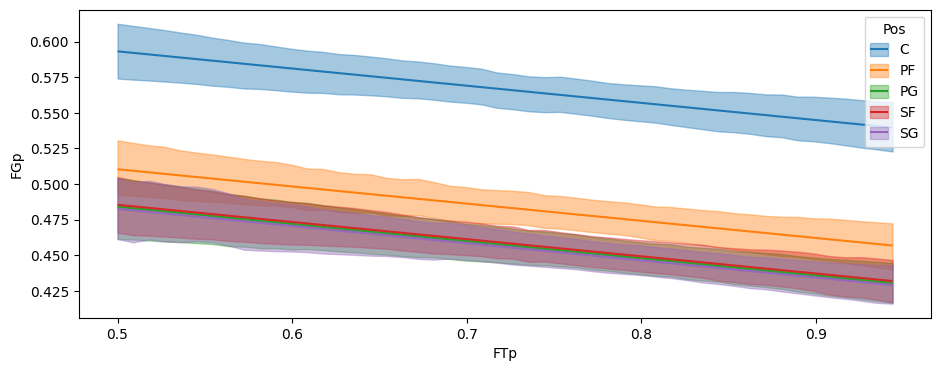

In [ ]:
#plot 94% HDIs of the means of each position
bmb.interpret.plot_predictions(model_basketball,
                               idata_basketball,
                                ["FTp",  "Pos"], fig_kwargs={"figsize":(11, 4)})

In [ ]:
#define the model, hierarchical
model_basketball_h = bmb.Model("`FGp` ~ (`FTp`|Pos)", data=bb)
#model
idata_basketball_h = model_basketball_h.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='FTp', ylabel='FGp'>], dtype=object))

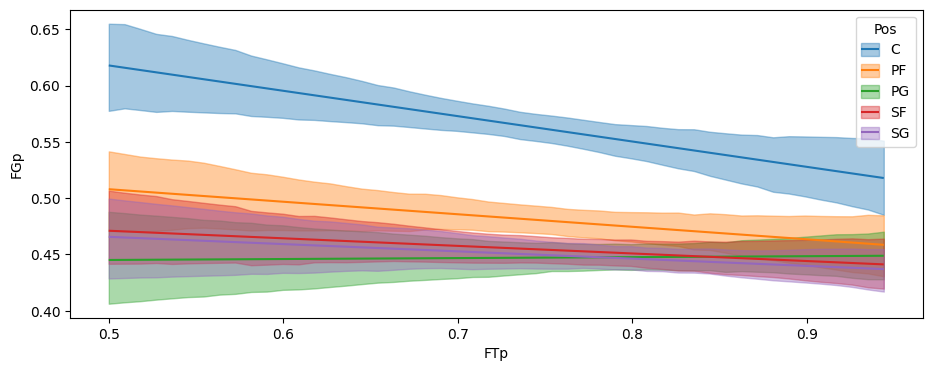

In [ ]:
bmb.interpret.plot_predictions(model_basketball_h,
                               idata_basketball_h,
                               ["FTp","Pos"],
                               fig_kwargs={"figsize":(11, 4)})

In [ ]:

#define the model; bb_interq
model_bb_interq = bmb.Model("`FGp` ~ `FTp` + `Pos` + `FTp`:`Pos`", data=bb)
#model
idata_bb_interq = model_bb_interq.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
bmb.interpret.plot_predictions(model_bb_interq,
                               idata_bb_interq,
                               ["FTp","3PA"],
                               fig_kwargs={"figsize":(11, 13)})

In [ ]:
#define the model; bb model 4

model_bb_4 = bmb.Model("`FGp` ~ `FTp` + `3PA` + `Pos` + `FTp`:`3PA` + `FTp`:`Pos` + `3PA` : `Pos`", data=bb)
idata_bb_4 = model_bb_4.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x1300 with 6 Axes>,
 array([[<Axes: title={'center': 'Pos = C'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: title={'center': 'Pos = PF'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: title={'center': 'Pos = PG'}, xlabel='FTp', ylabel='FGp'>],
        [<Axes: title={'center': 'Pos = SF'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: title={'center': 'Pos = SG'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: xlabel='FTp', ylabel='FGp'>]], dtype=object))

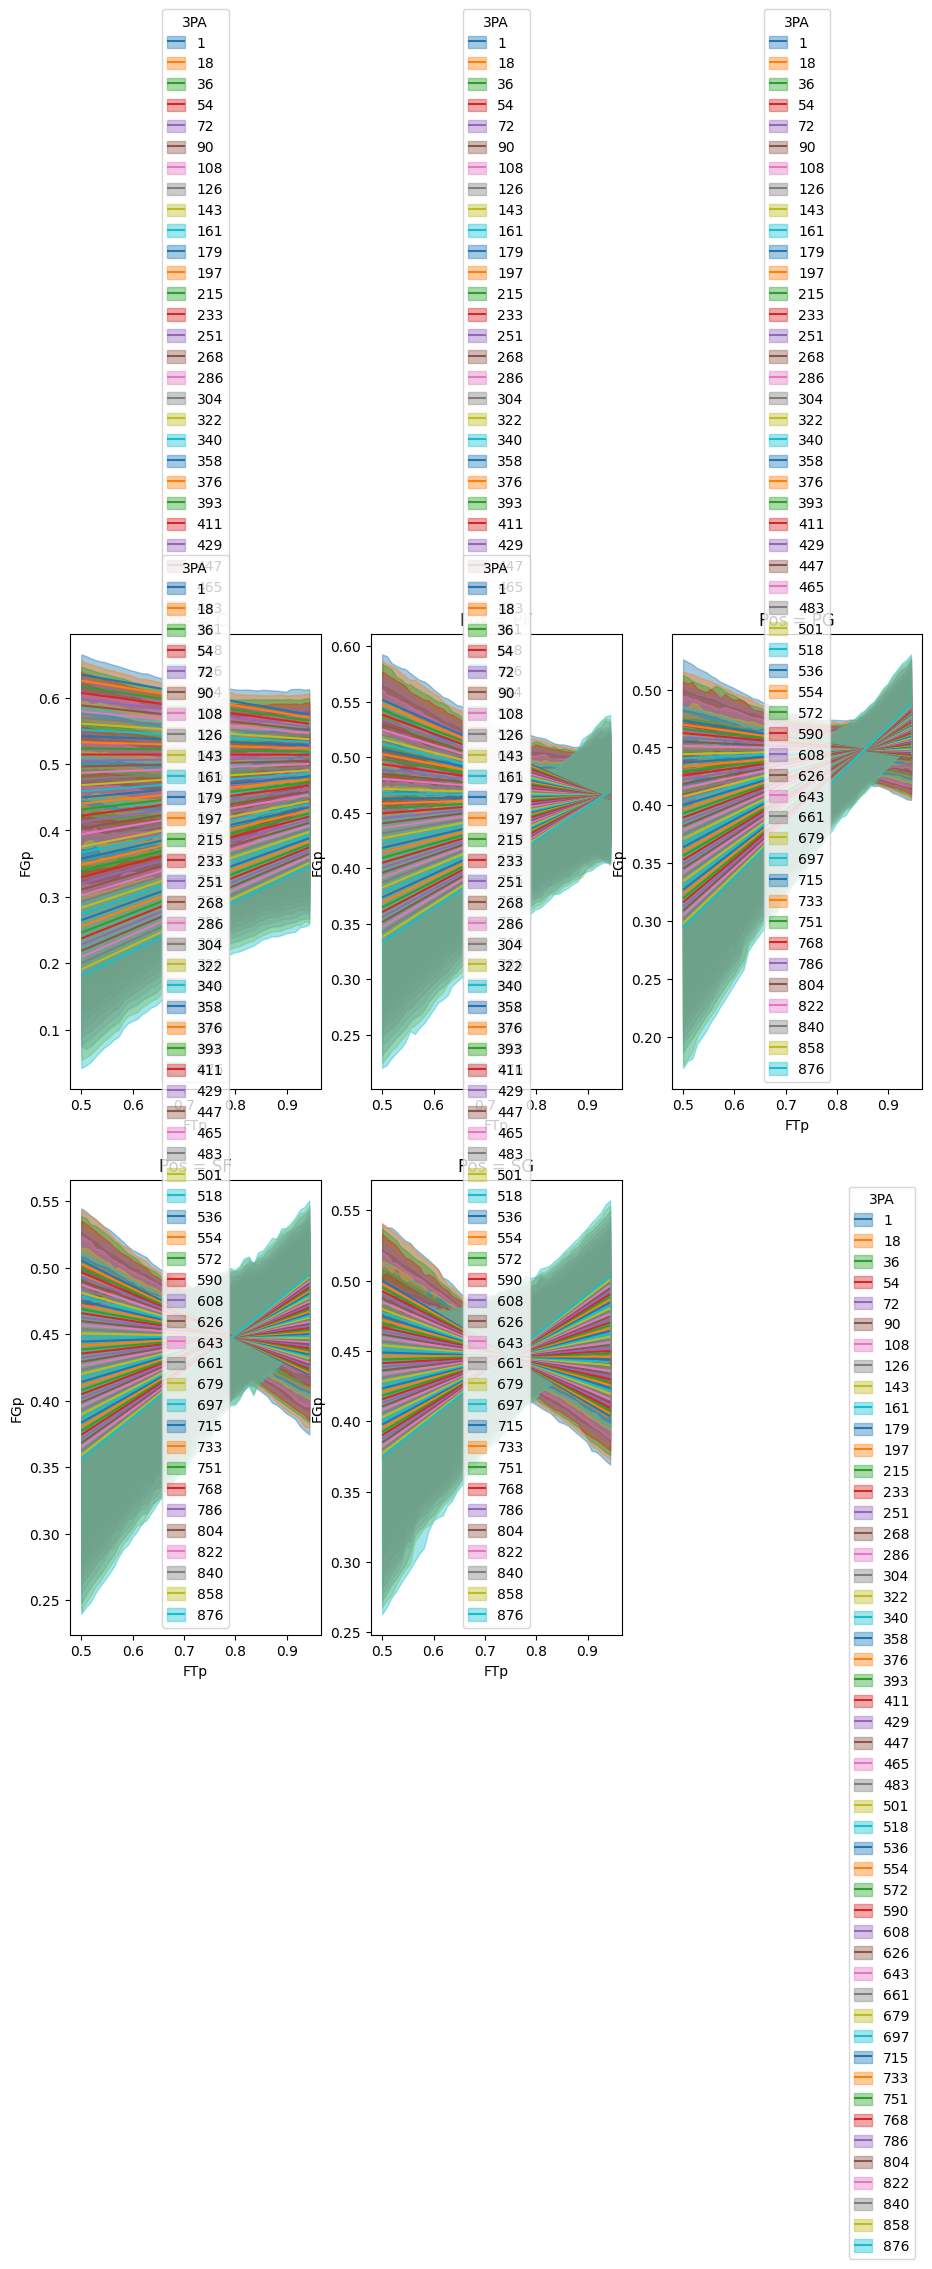

In [ ]:
bmb.interpret.plot_predictions(model_bb_4,
                               idata_bb_4,
                               ["FTp","3PA","Pos"],
                               fig_kwargs={"figsize":(11, 13)})

In [ ]:
model_bb_5 = bmb.Model("`FGp` ~ `FTp` + `3PA` + `Pos` + `3PA` : `Pos`", data=bb)
#create the model
idata_bb_5 = model_bb_5.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x1300 with 6 Axes>,
 array([[<Axes: title={'center': 'Pos = C'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: title={'center': 'Pos = PF'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: title={'center': 'Pos = PG'}, xlabel='FTp', ylabel='FGp'>],
        [<Axes: title={'center': 'Pos = SF'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: title={'center': 'Pos = SG'}, xlabel='FTp', ylabel='FGp'>,
         <Axes: xlabel='FTp', ylabel='FGp'>]], dtype=object))

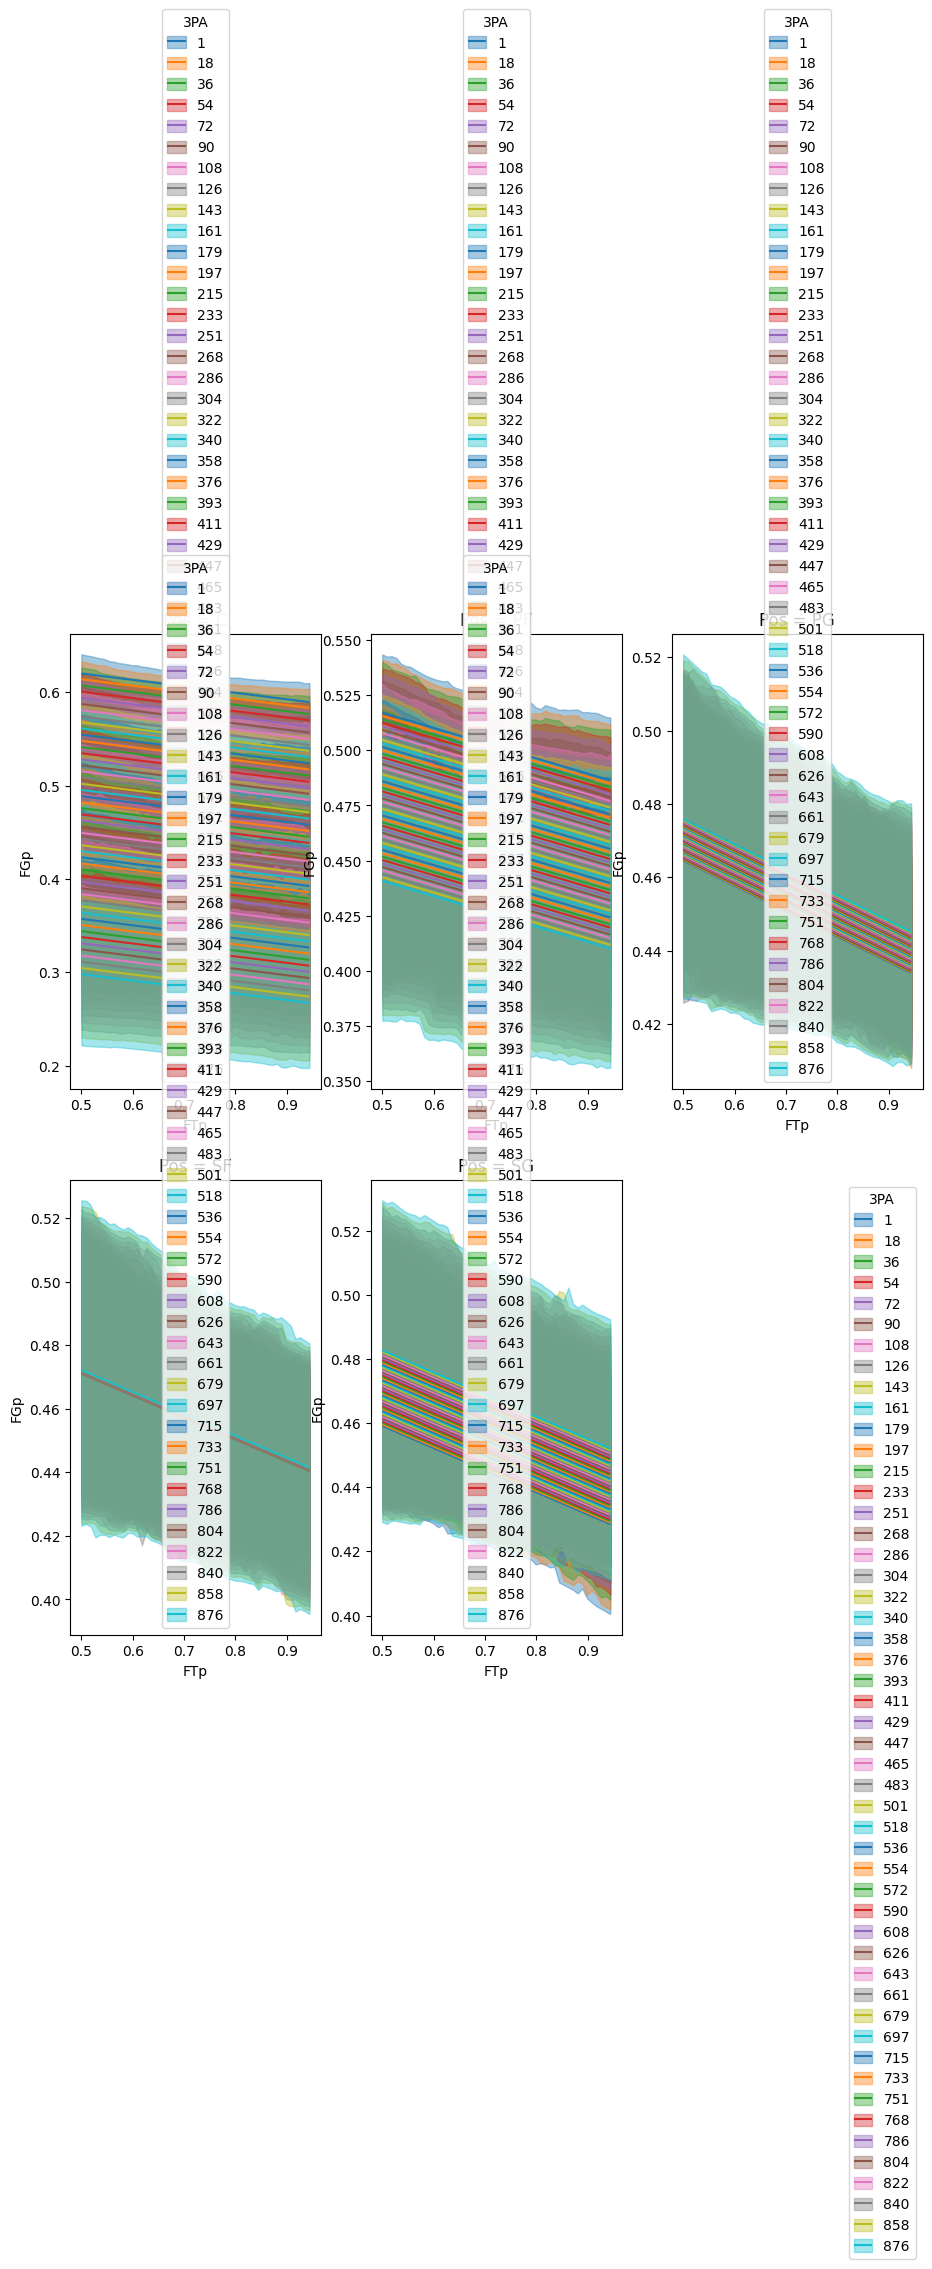

In [ ]:
bmb.interpret.plot_predictions(model_bb_5,
                               idata_bb_5,
                               ["FTp","3PA","Pos"],
                               fig_kwargs={"figsize":(11, 13)})#,
                               #legend=False)

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

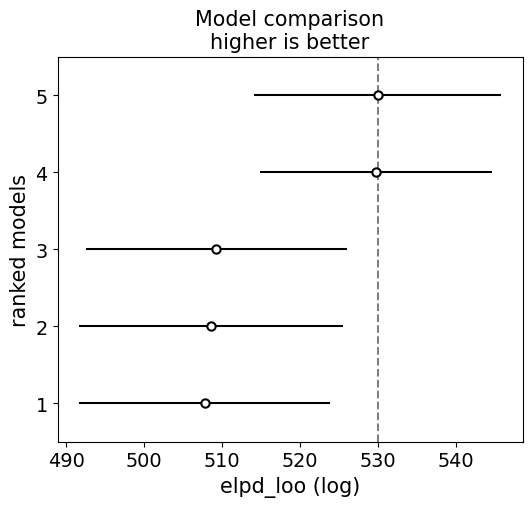

In [ ]:
cmp = az.compare({"1":idata_basketball,"2":idata_basketball_h, "3":idata_bb_interq, "4":idata_bb_4, "5": idata_bb_5})
az.plot_compare(cmp)

**Task11**:

Which model is "better" according to this metric?

Why do you think that is?

By comparison using elpd_loo, we can see that the best model is model 5, followed closely by model 4. This is likely because there is a correlation between position and 3Pa, leading to a better model. This slightly edges out model 4, which isn't as optimal because not all variables have a correlation.

**Task12:**

The body data set has a measure of body fat percentage (siri), as well as several other measurments of other parts of a person's body, plus their age.

Create a sensible causal diagram for this set of variables.

Based on your causal diagram, which variable should you try to predict? Why?

In [ ]:
body = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/body_fat.csv')

In [ ]:
body.head()

,siri,age,weight,height,abdomen,thigh,wrist
0,12.3,23,70.1,172,85.2,59.0,17.1
1,6.1,22,78.8,184,83.0,58.7,18.2
2,25.3,22,70.0,168,87.9,59.6,16.6
3,10.4,26,84.0,184,86.4,60.1,18.2
4,28.7,24,83.8,181,100.0,63.2,17.7


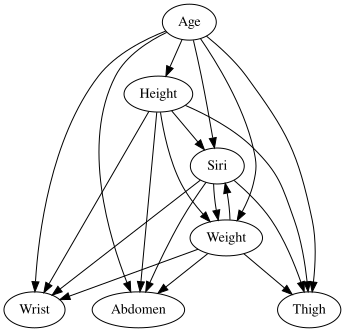

In [ ]:
b_dag = gv.Digraph(name= "Body DAG")

b_dag.node('S', 'Siri')
b_dag.node('A', 'Age')
b_dag.node('W', 'Weight')
b_dag.node('H', 'Height')
b_dag.node('B', 'Abdomen')
b_dag.node('T', 'Thigh')
b_dag.node('R', 'Wrist')

b_dag.edges(['AW', 'AH', 'AB', 'AT', 'AR', 'AS', 'HW', 'HB', 'HT', 'HR', 'HS', 'WB', 'WT', 'WR', 'SW', 'SB', 'ST', 'SR', 'WS'])

b_dag

Based on my causal diagram, we can predict siri and use it to model the wrist, abdomen, and thigh size, as all three of these variables can be correlated to body fat percentage.